# Grover's Algorithm and Quantum Amplitude Estimation

## Lecture 5

### Last Time
Shor's Algorithm: Factoring --> Order finding --> Quantum Phase Estimation --> Continued Fractions

### Today
1. Grover's Algorithm for Unstructured Search
3. Qiskit simulation of Grover search
4. Quantum amplitude estimation (QAE)
5. QAE simulation for estimating expected loss

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, StatePreparation
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)


def bits(j, n):
    return format(j, f'0{n}b')


def qft_circuit(n, do_swaps=True):
    qc = QuantumCircuit(n, name='QFT')
    for target in reversed(range(n)):
        qc.h(target)
        for control in reversed(range(target)):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
    if do_swaps:
        for q in range(n // 2):
            qc.swap(q, n - q - 1)
    return qc

# Search Problems

Grover's algorithm solves an unstructured search problem.

We have a search space of size

$$N=2^n,$$

whose elements are represented by computational basis states

$$|0\rangle, |1\rangle, \ldots, |N-1\rangle.$$

Some inputs are **marked**. The goal is to find a marked input using as few oracle calls as possible.

## Complexity

If there are $M$ marked items among $N$ total items, then a random classical guess succeeds with probability

$$\frac{M}{N}.$$

The expected number of checks is about

$$\frac{N}{M}.$$

If there is one marked item ($M = 1$), this is about $N$ checks.

Grover reduces this to

$$O\left(\sqrt{\frac{N}{M}}\right)$$

oracle calls.

## The phase oracle

Grover assumes a phase oracle $O_f$ that recognizes marked states:

$$O_f|x\rangle=(-1)^{f(x)}|x\rangle,$$

where

$$f(x)=\begin{cases}
1, & x\text{ is marked},\\
0, & x\text{ is unmarked}.
\end{cases}$$

So the oracle does not reveal the answer directly.

It only flips the sign of the marked amplitudes.

## From a checker to a phase oracle

Usually we first know how to build a reversible checker:

$$U_f|x\rangle|b\rangle=|x\rangle|b\oplus f(x)\rangle.$$

To turn this into a phase oracle, prepare the second qubit in

$$|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}.$$

Then

$$U_f|x\rangle|-\rangle
=|x\rangle\frac{|f(x)\rangle-|1\oplus f(x)\rangle}{\sqrt2}.$$

If $f(x)=0$, nothing changes.

If $f(x)=1$, the state becomes

$$-|x\rangle|-\rangle.$$

So the checker has become a phase oracle.

# The Starting State

Grover begins with the uniform superposition

$$|s\rangle=\frac{1}{\sqrt N}\sum_{x=0}^{N-1}|x\rangle.$$

This is easy to prepare:

$$|0\rangle^{\otimes n}\xrightarrow{H^{\otimes n}}|s\rangle.$$

At the start, every item has amplitude

$$\frac{1}{\sqrt N}.$$

The marked items are present, but they have tiny total probability when $M\ll N$.

## The diffuser: reflection around the average

The Grover diffuser is

$$D=2|s\rangle\langle s|-I.$$

For a state

$$|\psi\rangle=\sum_x a_x|x\rangle,$$

let the average amplitude be

$$\bar a=\frac{1}{N}\sum_x a_x.$$

Then the diffuser maps each amplitude to

$$a_x\mapsto 2\bar a-a_x.$$

That is why it is called **inversion about the mean**.

## Why $D$ reflects around the average

Start with

$$D|\psi\rangle=(2|s\rangle\langle s|-I)|\psi\rangle.$$

The overlap with the uniform state is

$$\langle s|\psi\rangle
=\left(\frac{1}{\sqrt N}\sum_y\langle y|\right)
\left(\sum_x a_x|x\rangle\right)
=\frac{1}{\sqrt N}\sum_x a_x
=\sqrt N\,\bar a.$$

Therefore

$$2|s\rangle\langle s|\psi\rangle
=2\sqrt N\,\bar a\left(\frac{1}{\sqrt N}\sum_x|x\rangle\right)
=2\bar a\sum_x|x\rangle.$$

Subtract $|\psi\rangle$:

$$D|\psi\rangle=\sum_x(2\bar a-a_x)|x\rangle.$$

## Constructing the Diffuser

The diffuser is

$$D=2|s\rangle\langle s|-I.$$

Since

$$|s\rangle=H^{\otimes n}|0\rangle,$$

we can rewrite

$$D=H^{\otimes n}(2|0\rangle\langle 0|-I)H^{\otimes n}.$$

$(2|0\rangle\langle 0|-I)$ just flips the phase of $|x\rangle$ if $x \neq 0$.

## One amplitude update by hand

Take $N=16$ and one marked state for a rough intuition.

Initially every amplitude is

$$\frac{1}{4}.$$

The oracle flips the marked amplitude:

$$\text{marked amplitude}:\quad \frac14\mapsto -\frac14.$$

The new average amplitude is

$$\bar a=\frac{15(1/4)+(-1/4)}{16}=\frac{14}{64}=\frac{7}{32}.$$

The diffuser maps each amplitude by

$$a_x\mapsto 2\bar a-a_x.$$

For the marked state:

$$-\frac14\mapsto 2\left(\frac{7}{32}\right)-\left(-\frac14\right)
=\frac{14}{32}+\frac{8}{32}=\frac{22}{32}=\frac{11}{16}.$$

One iteration made the marked amplitude much larger.

## One Grover iteration

A Grover iteration is

$$G=D O_f.$$

Read right to left:

1. $O_f$ flips the signs of marked amplitudes.
2. $D$ reflects all amplitudes around their average.

The first step pushes marked amplitudes below zero.

The second step reflects them high above the average.

Repeating this transfers amplitude from unmarked states into marked states.

# Two-Dimensional Picture

Let

$$|\beta\rangle=\frac{1}{\sqrt M}\sum_{x\text{ marked}}|x\rangle$$

be the equal superposition of marked states, and

$$|\alpha\rangle=\frac{1}{\sqrt{N-M}}\sum_{x\text{ unmarked}}|x\rangle$$

be the equal superposition of unmarked states.

The starting state is

$$|s\rangle
=\sqrt{\frac{N-M}{N}}|\alpha\rangle
+\sqrt{\frac{M}{N}}|\beta\rangle.$$

The entire algorithm stays in the plane spanned by $|\alpha\rangle$ and $|\beta\rangle$.

## Define the Grover angle

Write

$$|s\rangle=\sqrt{\frac{N-M}{N}}|\alpha\rangle
+\sqrt{\frac{M}{N}}|\beta\rangle = \cos\theta\,|\alpha\rangle+\sin\theta\,|\beta\rangle.$$

This gives

$$\sin\theta=\sqrt{\frac{M}{N}},$$

so

$$\theta=\arcsin\sqrt{\frac{M}{N}}.$$

The initial probability of measuring a marked state is

$$\sin^2\theta=\frac{M}{N}.$$

## What the two reflections do

The oracle acts as

$$O_f|\alpha\rangle=|\alpha\rangle,$$

because unmarked states are unchanged, and

$$O_f|\beta\rangle=-|\beta\rangle,$$

because marked states get a minus sign.

So $O_f$ is a reflection across the $|\alpha\rangle$ axis.

The diffuser

$$D=2|s\rangle\langle s|-I$$

is a reflection across the line pointing in the $|s\rangle$ direction.

$G = D O_f$ is a rotation by angle $2\theta$.

Let

$$
|s\rangle = \cos\theta\,|\alpha\rangle + \sin\theta\,|\beta\rangle = \begin{pmatrix}
\cos\theta \\
\sin\theta
\end{pmatrix}
$$

in the basis $\{|\alpha\rangle,|\beta\rangle\}$. The oracle is

$$
O_f =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}.
$$

The diffuser is

$$
D = 2|s\rangle\langle s| - I = 2
\begin{pmatrix}
\cos\theta \\
\sin\theta
\end{pmatrix}
\begin{pmatrix}
\cos\theta & \sin\theta
\end{pmatrix}
-
I
=
\begin{pmatrix}
\cos 2\theta & \sin 2\theta \\
\sin 2\theta & -\cos 2\theta
\end{pmatrix}.
$$

Therefore

$$
G = DO_f
=
\begin{pmatrix}
\cos 2\theta & \sin 2\theta \\
\sin 2\theta & -\cos 2\theta
\end{pmatrix}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
=
\begin{pmatrix}
\cos 2\theta & -\sin 2\theta \\
\sin 2\theta & \cos 2\theta
\end{pmatrix}.
$$

Thus $G$ is a rotation by angle $2\theta$ in the
$\{|\alpha\rangle,|\beta\rangle\}$ plane.

## The rotation formula

After $k$ Grover iterations,

$$G^k|s\rangle
=\cos((2k+1)\theta)|\alpha\rangle
+\sin((2k+1)\theta)|\beta\rangle.$$

Therefore the success probability is

$$P_{\text{success}}(k)=\sin^2((2k+1)\theta).$$

We want $(2k+1)\theta$ to be close to $\pi/2$.

Solve approximately:

$$2k\theta\approx\frac{\pi}{2},$$

so
$$k \approx \frac{\pi}{4 \theta}.$$

When $M \ll N$,

$$\theta\approx\sqrt{\frac{M}{N}},$$

so

$$k\approx\frac{\pi}{4}\sqrt{\frac{N}{M}}.$$

## Do not over-rotate

Grover does not monotonically improve forever.

Since each iteration is a rotation, the state can rotate past $|\beta\rangle$.

After that, the marked-state probability decreases.

This is why the iteration count matters:

$$k_{\text{opt}}\approx\left\lfloor\frac{\pi}{4}\sqrt{\frac{N}{M}}\right\rfloor.$$

If $M$ is unknown, one can use randomized iteration counts or amplitude estimation to learn the success amplitude.

# Visualizing Grover's Rotation

For a concrete example, take

$$N=16,\qquad M=2.$$

Then

$$\sin\theta=\sqrt{\frac{2}{16}}=\frac{1}{\sqrt8},$$

so

$$\theta\approx 0.361\text{ radians}.$$

The optimal number of iterations is about

$$\frac{\pi}{4}\sqrt{\frac{16}{2}}\approx 2.22,$$

so we expect $2$ Grover iterations to work well.

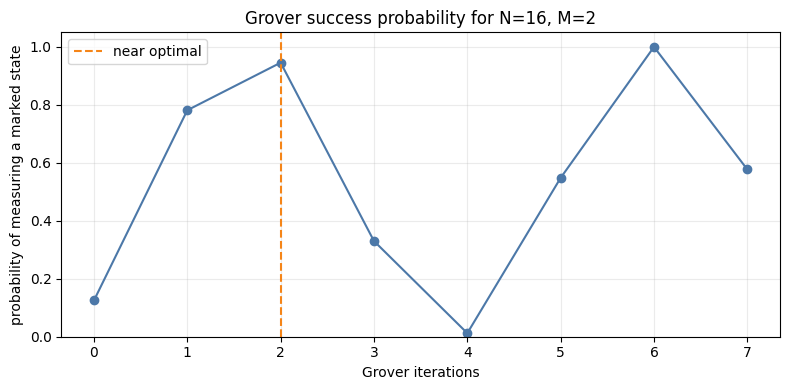

In [2]:
N = 16
M = 2
theta = np.arcsin(np.sqrt(M / N))
iterations = np.arange(0, 8)
success = np.sin((2 * iterations + 1) * theta) ** 2

plt.figure(figsize=(8, 4))
plt.plot(iterations, success, marker='o', color='#4c78a8')
plt.axvline(2, color='#f58518', linestyle='--', label='near optimal')
plt.ylim(0, 1.05)
plt.xlabel('Grover iterations')
plt.ylabel('probability of measuring a marked state')
plt.title('Grover success probability for N=16, M=2')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel(r'$|\alpha\rangle$ direction: unmarked')
ax.set_ylabel(r'$|\beta\rangle$ direction: marked')
ax.grid(alpha=0.25)
ax.plot([0, 1], [0, 0], color='black', linewidth=1)
ax.plot([0, 0], [0, 1], color='black', linewidth=1)

angles = (2 * iterations + 1) * theta
points = np.column_stack([np.cos(angles), np.sin(angles)])
ax.plot(points[:, 0], points[:, 1], color='#bab0ab', linestyle='--', marker='o', alpha=0.7)
vector, = ax.plot([], [], color='#e45756', linewidth=3)
label = ax.text(0.04, 0.95, '', transform=ax.transAxes, fontsize=12)

def update(frame):
    x, y = points[frame]
    vector.set_data([0, x], [0, y])
    label.set_text(f'k = {frame}, success = {success[frame]:.3f}')
    return vector, label

anim = FuncAnimation(fig, update, frames=len(iterations), interval=900, blit=True)
plt.close(fig)
display(HTML(anim.to_jshtml()))

# Qiskit Simulation: Grover Search

We will search a 4-qubit space:

$$N=2^4=16.$$

Mark two solutions:

$$|0110\rangle,\qquad |1011\rangle.$$

The exact implementation below uses matrix gates for the oracle and diffuser so that the math is transparent.

For larger real circuits, one would decompose these into reversible checking logic and multi-controlled phase gates.

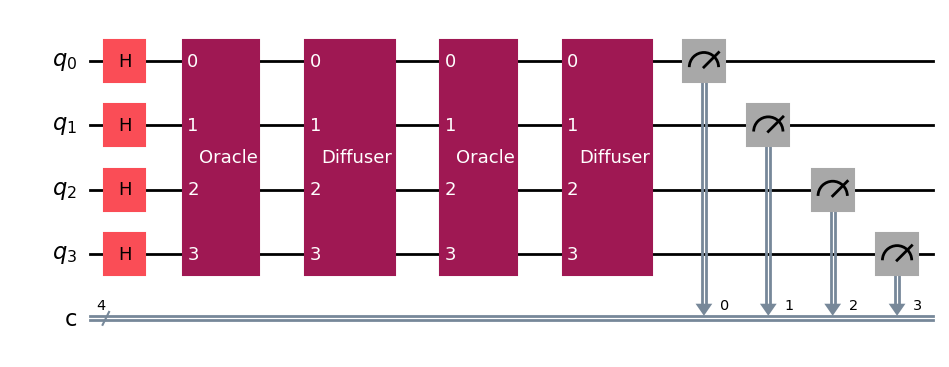

In [4]:
def phase_oracle_gate(n, marked_bitstrings):
    dim = 2 ** n
    diagonal = np.ones(dim, dtype=complex)
    for bitstring in marked_bitstrings:
        diagonal[int(bitstring, 2)] = -1
    return UnitaryGate(np.diag(diagonal), label='Oracle')


def diffuser_gate(n):
    dim = 2 ** n
    s = np.ones(dim, dtype=complex) / np.sqrt(dim)
    D = 2 * np.outer(s, s.conj()) - np.eye(dim)
    return UnitaryGate(D, label='Diffuser')


def grover_circuit(n, marked_bitstrings, iterations, measure=False):
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))

    oracle = phase_oracle_gate(n, marked_bitstrings)
    diffuser = diffuser_gate(n)

    for _ in range(iterations):
        qc.append(oracle, range(n))
        qc.append(diffuser, range(n))

    if measure:
        qc.measure(range(n), range(n))
    return qc


marked = ['0110', '1011']
grover_demo = grover_circuit(4, marked, iterations=2, measure=True)
grover_demo.draw(output='mpl')

In [5]:
def grover_probabilities(n, marked_bitstrings, max_iterations):
    rows = []
    for k in range(max_iterations + 1):
        qc = grover_circuit(n, marked_bitstrings, iterations=k, measure=False)
        state = Statevector.from_instruction(qc)
        probabilities = state.probabilities_dict()
        success_probability = sum(float(probabilities.get(bitstring, 0)) for bitstring in marked_bitstrings)
        rows.append((k, success_probability, probabilities))
    return rows


rows = grover_probabilities(4, marked, max_iterations=6)
for k, success_probability, _ in rows:
    print(f'{k} iterations: success probability = {success_probability:.4f}')

0 iterations: success probability = 0.1250
1 iterations: success probability = 0.7812
2 iterations: success probability = 0.9453
3 iterations: success probability = 0.3301
4 iterations: success probability = 0.0122
5 iterations: success probability = 0.5480
6 iterations: success probability = 0.9998


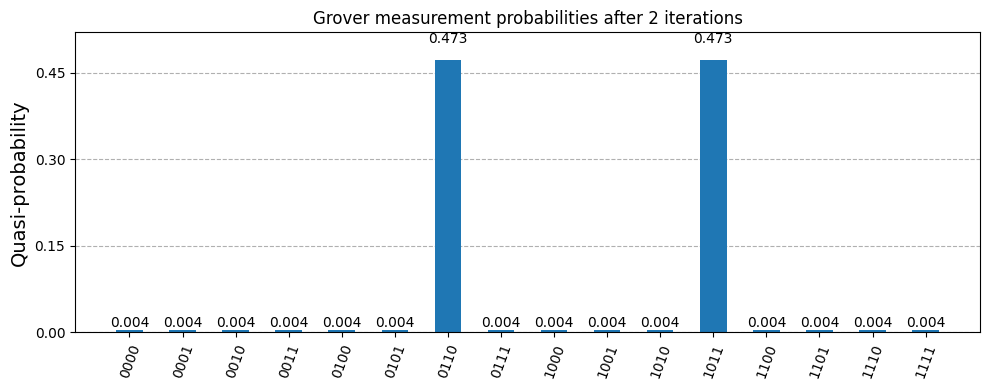

In [6]:
best_k = 2
_, _, best_probabilities = rows[best_k]
plot_histogram(best_probabilities, figsize=(10, 4), title=f'Grover measurement probabilities after {best_k} iterations')

## What the simulation shows

With no Grover iterations, the two marked states have total probability

$$\frac{2}{16}=0.125.$$

After one iteration, their total probability is already much larger.

After two iterations, the simulation gives success probability about

$$0.945.$$

After three iterations, the probability drops again because the state has over-rotated past the marked-state axis.

# Quantum Amplitude Estimation

### Amplitude Amplification

Grover is the special case where we start with a uniform superposition and amplify marked basis states.

More generally, suppose a circuit $A$ prepares

$$A|0\rangle=\sqrt{1-a}\,|\psi_0\rangle|0\rangle
+\sqrt a\,|\psi_1\rangle|1\rangle.$$

The last qubit marks success.

The number

$$a$$

is the success probability, or **amplitude squared**, that we want to learn or amplify.

## The amplitude angle

Write

$$a=\sin^2\theta.$$

Then

$$A|0\rangle=\cos\theta\,|\text{failure}\rangle+\sin\theta\,|\text{success}\rangle.$$

Amplitude amplification builds a Grover operator $Q$ from two reflections:

1. reflect around the success/failure split,
2. reflect around the prepared state $A|0\rangle$.

Just like Grover search, $Q$ rotates by angle $2\theta$ in the two-dimensional plane.

## Building the QAE Grover operator

Start with

$$A|0\rangle=\cos\theta|\text{failure}\rangle+\sin\theta|\text{success}\rangle.$$

Define a reflection that flips the success subspace:

$$S_{\text{success}}|\text{failure}\rangle=|\text{failure}\rangle,$$

$$S_{\text{success}}|\text{success}\rangle=-|\text{success}\rangle.$$

Define a reflection about the initial all-zero state:

$$S_0=I-2|0\rangle\langle 0|.$$

Then a standard amplitude-estimation Grover operator is

$$Q=-A S_0 A^\dagger S_{\text{success}}.$$

The operator $A S_0 A^\dagger$ reflects around the prepared state $A|0\rangle$.

## Why $Q$ has a phase to estimate

In the two-dimensional success/failure plane, write the prepared state as

$$|\psi\rangle=\cos\theta|\text{failure}\rangle+\sin\theta|\text{success}\rangle.$$

The Grover operator $Q$ is a rotation by angle $2\theta$ in this plane.

A real two-dimensional rotation has two complex eigenvalues:

$$e^{+2i\theta}\qquad\text{and}\qquad e^{-2i\theta}.$$

Phase estimation expects eigenvalues in the form

$$e^{2\pi i\phi}.$$

So the two possible phases are

$$\phi_+=\frac{\theta}{\pi},$$

and

$$\phi_-=-\frac{\theta}{\pi}\pmod 1=1-\frac{\theta}{\pi}.$$

The second one is not a new angle. It is just the negative rotation direction written as a number between $0$ and $1$.

## From QAE measurement to amplitude

Use $m$ evaluation qubits. Phase estimation returns an integer $y$ with

$$z=\frac{y}{2^m}.$$

Ideally, $z$ is close to one of the two phase fractions:

$$z\approx \frac{\theta}{\pi}$$

or

$$z\approx 1-\frac{\theta}{\pi}.$$

Both give the same amplitude because

$$\sin^2(\pi(1-z))=\sin^2(\pi z).$$

So the post-processing rule is

$$\widehat a=\sin^2(\pi z)=\sin^2\left(\pi\frac{y}{2^m}\right).$$

## Quantum amplitude estimation

Quantum amplitude estimation uses phase estimation on the Grover operator $Q$.

The eigenphases of $Q$ encode the amplitude angle:

$$Q|\psi_{+}\rangle=e^{+2i\theta}|\psi_{+}\rangle,$$

$$Q|\psi_{-}\rangle=e^{-2i\theta}|\psi_{-}\rangle.$$

Because QPE reports phases modulo $1$, the negative phase appears as

$$-\frac{\theta}{\pi}\pmod 1=1-\frac{\theta}{\pi}.$$

Either measured phase gives

$$a=\sin^2\theta.$$

## Why QAE matters

Many useful quantities can be written as probabilities or expectations.

Classical Monte Carlo estimates an expectation with error roughly

$$O\left(\frac{1}{\sqrt S}\right)$$

using $S$ samples.

Ideal QAE can achieve error roughly

$$O\left(\frac{1}{T}\right)$$

using $T$ applications of the state-preparation and Grover operators.

That quadratic improvement is why QAE is often discussed for finance, risk analysis, counting, reliability estimation, and simulation problems.

# QAE for Grover with Unknown $M$

In Grover's algorithm, the best iteration count depends on the number of marked inputs:

$$k_{\text{opt}}\approx \frac{\pi}{4}\sqrt{\frac{N}{M}}.$$

But what if we do not know $M$?

The marked fraction is

$$a=\frac{M}{N}.$$

That is exactly an amplitude-estimation problem.

If QAE estimates $a$, then we estimate

$$\widehat M=N\widehat a,$$

and choose approximately

$$\widehat k_{\text{opt}}\approx \frac{\pi}{4}\frac{1}{\sqrt{\widehat a}}.$$

## How to turn Grover into counting

Use the same search preparation as Grover:

$$A|0\rangle=H^{\otimes n}|0\rangle=\frac{1}{\sqrt N}\sum_x |x\rangle.$$

The success subspace is the span of the marked states.

Therefore

$$a=\Pr[\text{marked}]=\frac{M}{N}.$$

QAE estimates this probability without first knowing $M$.

This is often called **quantum counting**.

## Example setup

We reuse the earlier Grover search space:

$$N=16.$$

There are secretly two marked states:

$$|0110\rangle,\qquad |1011\rangle.$$

So the true values are

$$M=2,$$

and

$$a=\frac{M}{N}=\frac{2}{16}=0.125.$$

In the simulation below, QAE only sees the oracle. It estimates $a$, then infers $M$.

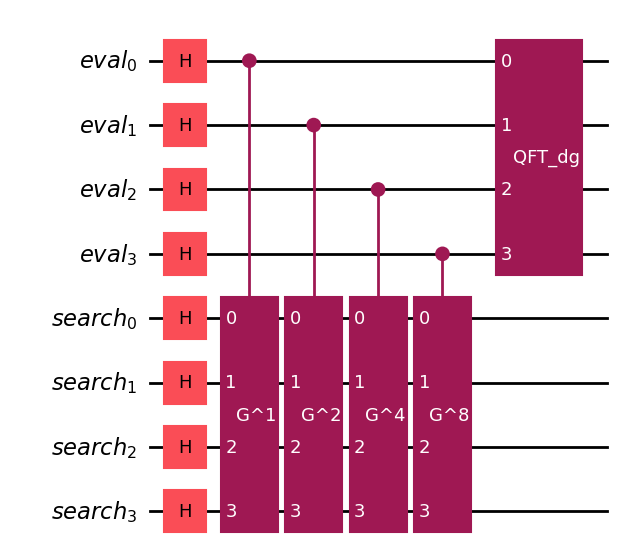

In [7]:
def grover_matrix_for_marked(n, marked_bitstrings):
    dim = 2 ** n

    oracle_diagonal = np.ones(dim, dtype=complex)
    for bitstring in marked_bitstrings:
        oracle_diagonal[int(bitstring, 2)] = -1
    oracle_matrix = np.diag(oracle_diagonal)

    uniform = np.ones(dim, dtype=complex) / np.sqrt(dim)
    diffuser_matrix = 2 * np.outer(uniform, uniform.conj()) - np.eye(dim)

    return diffuser_matrix @ oracle_matrix


def grover_counting_qae_circuit(n, marked_bitstrings, m_eval=7):
    grover_matrix = grover_matrix_for_marked(n, marked_bitstrings)

    eval_register = QuantumRegister(m_eval, name='eval')
    search_register = QuantumRegister(n, name='search')
    qc = QuantumCircuit(eval_register, search_register)

    # Phase-estimation register.
    qc.h(eval_register)

    # A = H^n prepares the uniform search state.
    qc.h(search_register)

    for j, q in enumerate(eval_register):
        G_power = np.linalg.matrix_power(grover_matrix, 2 ** j)
        controlled_G_power = UnitaryGate(G_power, label=f'G^{2 ** j}').control(1)
        qc.append(controlled_G_power, [q] + list(search_register))

    qc.append(qft_circuit(m_eval).inverse(), eval_register)
    return qc


counting_demo = grover_counting_qae_circuit(4, marked, m_eval=4)
counting_demo.draw(output='mpl')

In [8]:
m_eval_counting = 7
counting_qc = grover_counting_qae_circuit(4, marked, m_eval=m_eval_counting)
counting_state = Statevector.from_instruction(counting_qc)
counting_probabilities = counting_state.probabilities_dict(qargs=range(m_eval_counting))

N_search = 2 ** 4
true_M = len(marked)
true_a = true_M / N_search

def marked_fraction_from_bits(bitstring, m_eval):
    y = int(bitstring, 2)
    z = y / (2 ** m_eval)
    a_hat = np.sin(np.pi * z) ** 2
    M_hat = N_search * a_hat
    if a_hat > 0:
        k_hat = np.pi / (4 * np.sqrt(a_hat))
    else:
        k_hat = np.inf
    return y, z, a_hat, M_hat, k_hat

top_counting = sorted(counting_probabilities.items(), key=lambda item: item[1], reverse=True)[:8]
print(f'True marked count M = {true_M}')
print(f'True marked fraction a = M/N = {true_a:.5f}')
print('\nMost likely QAE outcomes for quantum counting:')
for bitstring, probability in top_counting:
    y, z, a_hat, M_hat, k_hat = marked_fraction_from_bits(bitstring, m_eval_counting)
    print(
        f'bits={bitstring}, y={y:3d}, probability={probability:.4f}, '
        f'a_hat={a_hat:.5f}, M_hat={M_hat:.3f}, k_hat≈{k_hat:.2f}'
    )

best_counting_bits = top_counting[0][0]
_, _, best_a_hat, best_M_hat, best_k_hat = marked_fraction_from_bits(best_counting_bits, m_eval_counting)
print(f'\nBest estimate: M_hat = {best_M_hat:.3f}')
print(f'Recommended Grover iterations: round({best_k_hat:.2f}) = {round(best_k_hat)}')

True marked count M = 2
True marked fraction a = M/N = 0.12500

Most likely QAE outcomes for quantum counting:
bits=0001111, y= 15, probability=0.3862, a_hat=0.12952, M_hat=2.072, k_hat≈2.18
bits=1110001, y=113, probability=0.3862, a_hat=0.12952, M_hat=2.072, k_hat≈2.18
bits=0001110, y= 14, probability=0.0565, a_hat=0.11349, M_hat=1.816, k_hat≈2.33
bits=1110010, y=114, probability=0.0565, a_hat=0.11349, M_hat=1.816, k_hat≈2.33
bits=0010000, y= 16, probability=0.0182, a_hat=0.14645, M_hat=2.343, k_hat≈2.05
bits=1110000, y=112, probability=0.0182, a_hat=0.14645, M_hat=2.343, k_hat≈2.05
bits=0001101, y= 13, probability=0.0100, a_hat=0.09840, M_hat=1.574, k_hat≈2.50
bits=1110011, y=115, probability=0.0100, a_hat=0.09840, M_hat=1.574, k_hat≈2.50

Best estimate: M_hat = 2.072
Recommended Grover iterations: round(2.18) = 2


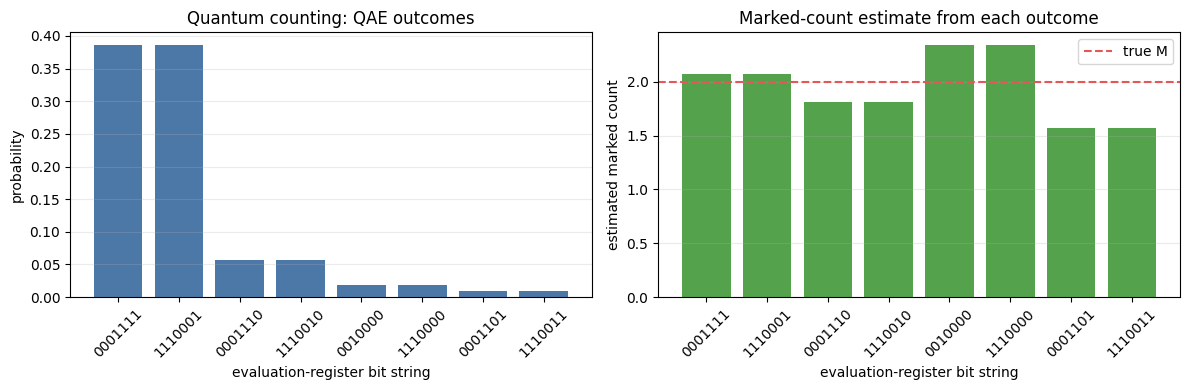

In [9]:
counting_labels = [bits for bits, _ in top_counting]
counting_values = [prob for _, prob in top_counting]
counting_M_estimates = [marked_fraction_from_bits(bits, m_eval_counting)[3] for bits, _ in top_counting]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counting_labels, counting_values, color='#4c78a8')
axes[0].set_title('Quantum counting: QAE outcomes')
axes[0].set_xlabel('evaluation-register bit string')
axes[0].set_ylabel('probability')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(counting_labels, counting_M_estimates, color='#54a24b')
axes[1].axhline(true_M, color='#e45756', linestyle='--', label='true M')
axes[1].set_title('Marked-count estimate from each outcome')
axes[1].set_xlabel('evaluation-register bit string')
axes[1].set_ylabel('estimated marked count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()

## What quantum counting gives Grover

For this example, QAE estimates

$$M\approx 2.$$

Then Grover can choose

$$k\approx\frac{\pi}{4}\sqrt{\frac{16}{2}}\approx 2.22,$$

so we run about $2$ Grover iterations.

That matches the earlier simulation, where two iterations gave success probability about $0.945$.

The bigger idea:

> QAE can be used as a counting subroutine that tells Grover how long to rotate when the number of marked inputs is unknown.

## When QAE is useful

QAE is most useful when the problem already looks like Monte Carlo:

$$\text{estimate }\mathbb E[f(X)]\text{ or }\Pr[\text{event}].$$

Examples:

1. count how many inputs satisfy a condition,
2. estimate risk or expected loss,
3. price a derivative (Phys. Rev. A 98, 022321),
4. estimate a tail probability or the probability of system failure,
5. estimate an integral.

The catch is that QAE needs coherent access to the model through $A$, $A^\dagger$, and controlled powers of the Grover operator $Q$.

So QAE is useful when state preparation is efficient and repeated sampling would be expensive.

# Summary

Grover's algorithm starts with a small marked-state amplitude and repeatedly applies two reflections.

Those reflections produce a rotation toward the marked subspace.

After about

$$\frac{\pi}{4}\sqrt{\frac{N}{M}}$$

iterations, measuring finds a marked state with high probability.

QAE uses the same rotation, but instead of only amplifying the amplitude, it estimates the rotation angle.

That lets us estimate probabilities and expectations with a quadratic improvement over ordinary Monte Carlo.

# QAE Example: Estimating Expected Loss

Suppose a tiny portfolio has eight equally likely scenarios.

The losses, measured in dollars, are

| Scenario | Loss |
|---:|---:|
| 0 | 2 |
| 1 | 5 |
| 2 | 8 |
| 3 | 12 |
| 4 | 18 |
| 5 | 25 |
| 6 | 35 |
| 7 | 50 |

The true expected loss is

$$\mathbb E[L]=19.375.$$

We will estimate it using QAE.

## Encoding the expected value as an amplitude

Let $L_{\max}=100$ and define normalized losses

$$\ell_x=\frac{L_x}{L_{\max}}.$$

Build a circuit $A$ that prepares

$$A|0\rangle
=\frac{1}{\sqrt 8}\sum_{x=0}^7 |x\rangle
\left(\sqrt{1-\ell_x}|0\rangle+\sqrt{\ell_x}|1\rangle\right).$$

The probability of measuring the objective qubit as $1$ is

$$a=\frac{1}{8}\sum_{x=0}^7 \ell_x
=\frac{\mathbb E[L]}{L_{\max}}.$$

So once QAE estimates $a$, we multiply by $L_{\max}$ to estimate $\mathbb E[L]$.

## QAE circuit structure

The QAE circuit has three conceptual parts:

1. Prepare the model state using $A$.
2. Run phase estimation on the Grover operator $Q$.
3. Convert the measured phase estimate into

$$\widehat a=\sin^2\left(\pi\frac{y}{2^m}\right).$$

Then

$$\widehat{\mathbb E[L]}=L_{\max}\widehat a.$$

Here $m$ is the number of evaluation qubits used by phase estimation.

In [10]:
def expected_loss_state_preparation(losses, probabilities=None, loss_max=100):
    losses = np.asarray(losses, dtype=float)
    normalized_losses = losses / loss_max
    n_data = int(np.log2(len(losses)))
    if 2 ** n_data != len(losses):
        raise ValueError('The number of scenarios must be a power of 2.')

    if probabilities is None:
        probabilities = np.ones(len(losses)) / len(losses)
    probabilities = np.asarray(probabilities, dtype=float)

    total_qubits = n_data + 1
    objective_qubit = n_data
    state = np.zeros(2 ** total_qubits, dtype=complex)

    for x, (probability, loss_fraction) in enumerate(zip(probabilities, normalized_losses)):
        state[x] = np.sqrt(probability) * np.sqrt(1 - loss_fraction)
        state[x + (1 << objective_qubit)] = np.sqrt(probability) * np.sqrt(loss_fraction)

    A = QuantumCircuit(total_qubits, name='A')
    A.append(StatePreparation(state), range(total_qubits))
    return A, state


def grover_operator_for_amplitude_estimation(A, objective_qubit):
    A_matrix = Operator(A).data
    dim = A_matrix.shape[0]

    # S_good flips the phase when the objective qubit is |1>.
    S_good = np.eye(dim, dtype=complex)
    for basis_index in range(dim):
        if (basis_index >> objective_qubit) & 1:
            S_good[basis_index, basis_index] = -1

    # S_zero flips the all-zero state. The global minus sign gives the standard QAE phase convention.
    S_zero = np.eye(dim, dtype=complex)
    S_zero[0, 0] = -1

    return -A_matrix @ S_zero @ A_matrix.conj().T @ S_good


def qae_circuit_for_expected_loss(losses, probabilities=None, loss_max=100, m_eval=8):
    A, _ = expected_loss_state_preparation(losses, probabilities, loss_max)
    n_model = A.num_qubits
    objective_qubit = n_model - 1
    Q_matrix = grover_operator_for_amplitude_estimation(A, objective_qubit)

    eval_register = QuantumRegister(m_eval, name='eval')
    model_register = QuantumRegister(n_model, name='model')
    qc = QuantumCircuit(eval_register, model_register)

    qc.h(eval_register)
    qc.append(A, model_register)

    for j, q in enumerate(eval_register):
        Q_power = np.linalg.matrix_power(Q_matrix, 2 ** j)
        controlled_Q_power = UnitaryGate(Q_power, label=f'Q^{2 ** j}').control(1)
        qc.append(controlled_Q_power, [q] + list(model_register))

    qc.append(qft_circuit(m_eval).inverse(), eval_register)
    return qc

True expected loss = $19.375
True amplitude a = E[L]/L_max = 0.19375


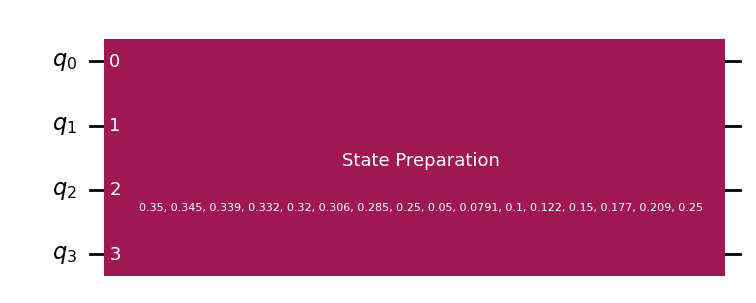

In [11]:
losses = np.array([2, 5, 8, 12, 18, 25, 35, 50], dtype=float)
loss_max = 100
true_expected_loss = float(np.mean(losses))
true_amplitude = true_expected_loss / loss_max

print(f'True expected loss = ${true_expected_loss:.3f}')
print(f'True amplitude a = E[L]/L_max = {true_amplitude:.5f}')

A_loss, _ = expected_loss_state_preparation(losses, loss_max=loss_max)
A_loss.draw(output='mpl')

In [12]:
m_eval = 8
qae_qc = qae_circuit_for_expected_loss(losses, loss_max=loss_max, m_eval=m_eval)
state = Statevector.from_instruction(qae_qc)
phase_probabilities = state.probabilities_dict(qargs=range(m_eval))

def amplitude_estimate_from_bits(bitstring):
    y = int(bitstring, 2)
    phase_fraction = y / (2 ** m_eval)
    amplitude = np.sin(np.pi * phase_fraction) ** 2
    return y, phase_fraction, amplitude

top_qae = sorted(phase_probabilities.items(), key=lambda item: item[1], reverse=True)[:10]
print('Most likely QAE measurement outcomes:')
for bitstring, probability in top_qae:
    y, phase_fraction, amplitude = amplitude_estimate_from_bits(bitstring)
    expected_loss_estimate = loss_max * amplitude
    print(
        f'bits={bitstring}, y={y:3d}, probability={probability:.4f}, '
        f'a_hat={amplitude:.5f}, E[L]_hat=${expected_loss_estimate:.3f}'
    )

best_bitstring = top_qae[0][0]
_, _, best_amplitude = amplitude_estimate_from_bits(best_bitstring)
best_expected_loss = loss_max * best_amplitude
print(f'\nBest estimate from most likely outcome: ${best_expected_loss:.3f}')
print(f'Absolute error: ${abs(best_expected_loss - true_expected_loss):.3f}')

Most likely QAE measurement outcomes:
bits=11011011, y=219, probability=0.4682, a_hat=0.19238, E[L]_hat=$19.238
bits=00100101, y= 37, probability=0.4682, a_hat=0.19238, E[L]_hat=$19.238
bits=11011010, y=218, probability=0.0126, a_hat=0.20215, E[L]_hat=$20.215
bits=00100110, y= 38, probability=0.0126, a_hat=0.20215, E[L]_hat=$20.215
bits=11011100, y=220, probability=0.0072, a_hat=0.18280, E[L]_hat=$18.280
bits=00100100, y= 36, probability=0.0072, a_hat=0.18280, E[L]_hat=$18.280
bits=11011001, y=217, probability=0.0027, a_hat=0.21210, E[L]_hat=$21.210
bits=00100111, y= 39, probability=0.0027, a_hat=0.21210, E[L]_hat=$21.210
bits=11011101, y=221, probability=0.0020, a_hat=0.17341, E[L]_hat=$17.341
bits=00100011, y= 35, probability=0.0020, a_hat=0.17341, E[L]_hat=$17.341

Best estimate from most likely outcome: $19.238
Absolute error: $0.137


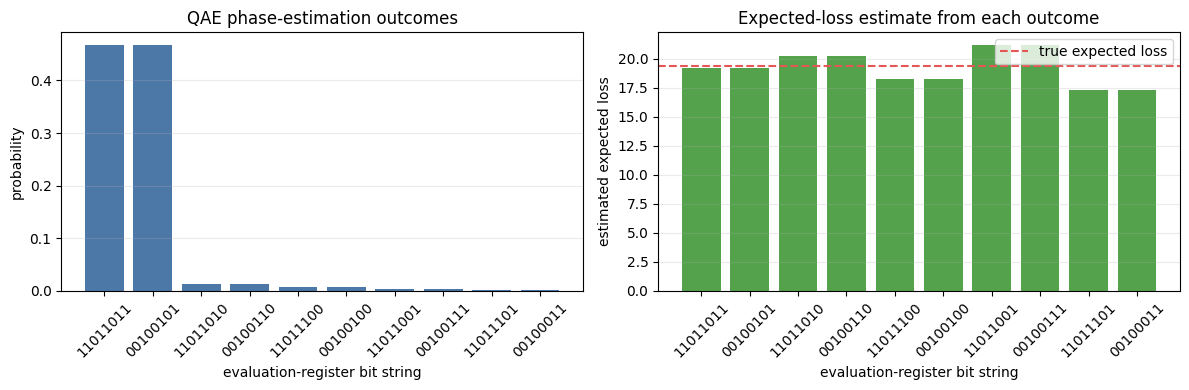

In [13]:
plot_items = top_qae
labels = [item[0] for item in plot_items]
values = [item[1] for item in plot_items]
estimates = [loss_max * amplitude_estimate_from_bits(bitstring)[2] for bitstring, _ in plot_items]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, values, color='#4c78a8')
axes[0].set_title('QAE phase-estimation outcomes')
axes[0].set_xlabel('evaluation-register bit string')
axes[0].set_ylabel('probability')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(labels, estimates, color='#54a24b')
axes[1].axhline(true_expected_loss, color='#e45756', linestyle='--', label='true expected loss')
axes[1].set_title('Expected-loss estimate from each outcome')
axes[1].set_xlabel('evaluation-register bit string')
axes[1].set_ylabel('estimated expected loss')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()

## What the QAE simulation shows

The true value is

$$\mathbb E[L]=19.375.$$

With $m=8$ evaluation qubits, the most likely QAE outcome gives an estimate close to this value.

The important conceptual point is the workflow:

$$\text{expected value}\to\text{amplitude}\to\text{phase}\to\text{measurement}\to\text{estimate}.$$

QAE is useful when:

1. the quantity can be encoded as an amplitude,
2. state preparation and its inverse are not too expensive,
3. oracle/Grover calls are the bottleneck,
4. we need better scaling than classical Monte Carlo.